In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [5]:
df = pd.read_csv('AB_NYC_2019.csv.zip')

df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


##DATASET OVERVIEW
we know the details about shape, columns, info and statistical analysis of the dataset

In [6]:
df.shape

(48895, 16)

In [7]:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [9]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


##DATA INTEGRITY CHECK
we check for missing values and replace them with alternative values to get better analysis

In [10]:
df.isnull().sum()

,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


we observe that null values present in columns like hostname, name, last_review, reviews_per_month.. lets make this possible to fill them with alternatives

In [11]:
df['host_name'].fillna('Unknown', inplace=True)

In [12]:
df['name'].fillna('No Name', inplace=True)

In [13]:
df['reviews_per_month'].fillna(
    df['reviews_per_month'].median(),
    inplace=True
)

In [14]:
df['last_review'].fillna(
    'Not Reviewed',
    inplace=True
)

In [15]:
df.isnull().sum()

,0
id,0
name,0
host_id,0
host_name,0
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


yepp. here we remove null values.. and this process is called DATA HANDLING.. lets go with duplicates handling

In [16]:
df.duplicated().sum()

np.int64(0)

here we can understand that there are no duplicate values .. so we can go further ..thst is "STANDARDISATION"
1. Convert Column Names to Lowercase
2. Replace Spaces with Underscores

In [19]:
df.columns = df.columns.str.lower()

In [20]:
df.columns = df.columns.str.replace(' ', '_')

In [21]:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

##DATATYPE CONVERSION

In [22]:
df['last_review'] = pd.to_datetime(
    df['last_review'],
    errors='coerce'
)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              48895 non-null  int64         
 1   name                            48895 non-null  object        
 2   host_id                         48895 non-null  int64         
 3   host_name                       48895 non-null  object        
 4   neighbourhood_group             48895 non-null  object        
 5   neighbourhood                   48895 non-null  object        
 6   latitude                        48895 non-null  float64       
 7   longitude                       48895 non-null  float64       
 8   room_type                       48895 non-null  object        
 9   price                           48895 non-null  int64         
 10  minimum_nights                  48895 non-null  int64         
 11  nu

##OUTLIER DETECTION

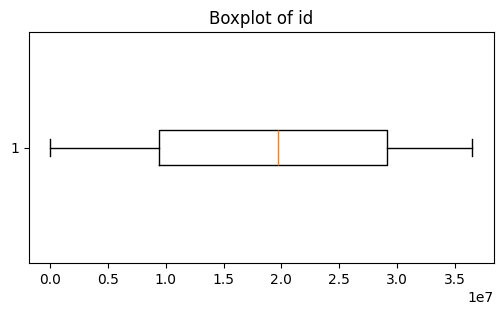

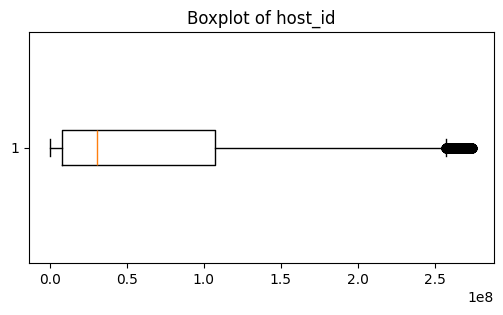

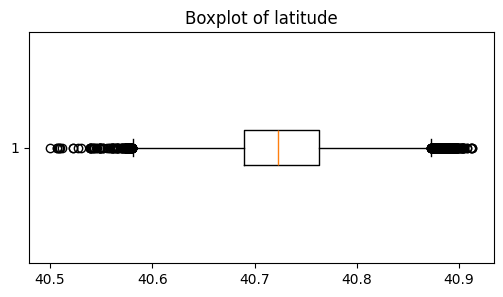

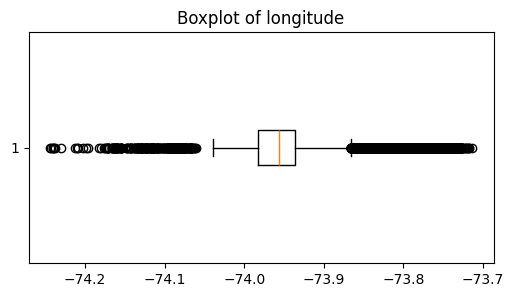

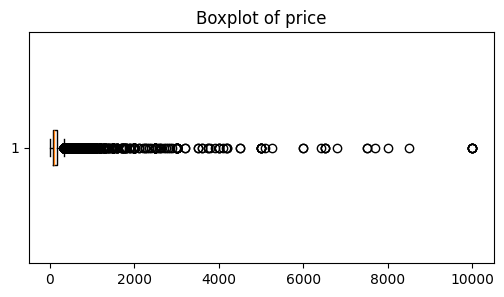

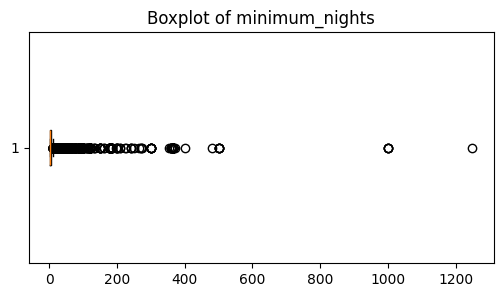

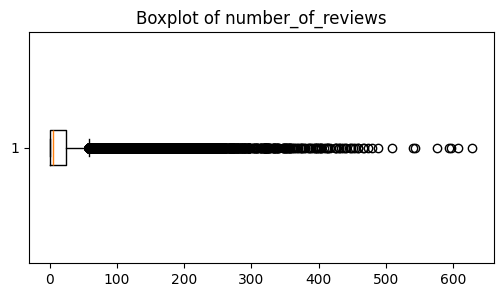

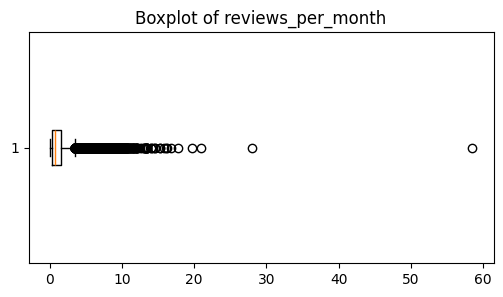

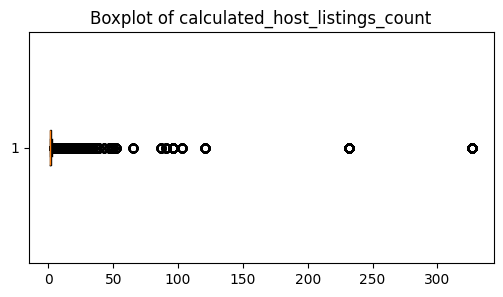

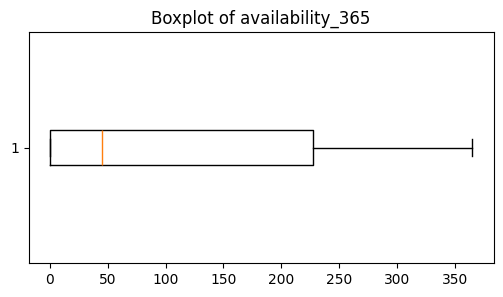

In [25]:
import matplotlib.pyplot as plt

num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    plt.figure(figsize=(6,3))
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(f'Boxplot of {col}')
    plt.show()

we can understand that the colums {price, min nights} have outliers .. so remove extreme outliers

In [26]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

df = df[
    (df['price'] >= lower) &
    (df['price'] <= upper)
]

In [27]:
Q1 = df['minimum_nights'].quantile(0.25)
Q3 = df['minimum_nights'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

df = df[
    (df['minimum_nights'] >= lower) &
    (df['minimum_nights'] <= upper)
]

now lets verify the dataset that outliers are removed or not by knowing the information of the dataset

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 39738 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              39738 non-null  int64         
 1   name                            39738 non-null  object        
 2   host_id                         39738 non-null  int64         
 3   host_name                       39738 non-null  object        
 4   neighbourhood_group             39738 non-null  object        
 5   neighbourhood                   39738 non-null  object        
 6   latitude                        39738 non-null  float64       
 7   longitude                       39738 non-null  float64       
 8   room_type                       39738 non-null  object        
 9   price                           39738 non-null  int64         
 10  minimum_nights                  39738 non-null  int64         
 11  number_

In [30]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
count,3.973800e+04,3.973800e+04,39738.000000,39738.000000,39738.000000,39738.000000,39738.000000,33037,39738.000000,39738.000000,39738.000000
mean,1.883347e+07,6.621640e+07,40.727573,-73.949146,119.001258,2.696160,26.377548,2018-10-08 03:56:12.037412608,1.353536,3.073054,97.169837
min,2.539000e+03,2.571000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,2011-03-28 00:00:00,0.010000,1.000000,0.000000
25%,9.415224e+06,7.824440e+06,40.688080,-73.981040,65.000000,1.000000,1.000000,2018-07-13 00:00:00,0.290000,1.000000,0.000000
50%,1.947302e+07,3.073608e+07,40.720080,-73.953320,100.000000,2.000000,7.000000,2019-05-26 00:00:00,0.720000,1.000000,25.000000
75%,2.861316e+07,1.036117e+08,40.763260,-73.932170,154.750000,3.000000,29.000000,2019-06-24 00:00:00,1.890000,2.000000,179.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,334.000000,11.000000,629.000000,2019-07-08 00:00:00,58.500000,327.000000,365.000000
std,1.084328e+07,7.750186e+07,0.056293,0.047708,67.184264,1.863537,47.474653,NaN,1.614805,19.743865,124.366313


In [31]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaT,0.72,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


hence, the dataset is ready to download for machine learning purposes

##Key Findings
1. Missing Data Handling

Filled missing values in name and host_name.

Replaced missing reviews_per_month using median.

Handled missing last_review values.

2. Duplicate Removal

Removed duplicate records to maintain uniqueness.

3. Standardization

Standardized column names.

Converted date columns into datetime format.

4. Outlier Detection

Detected outliers using boxplots and IQR method.

Removed extreme values from price and minimum_nights.

5. Data Integrity

Ensured dataset consistency and reliability.

Prepared data for further analysis and machine learning.